# Day 5: Overfitting and Underfitting

This lesson explains how models learn, why the right complexity matters, and how regularization helps generalization. We compare underfitting, overfitting, and the bias-variance tradeoff with examples and code.

## Key Concepts

- **Underfitting**: The model is too simple and cannot capture the pattern in the data. Errors are high on both training and test sets.
- **Overfitting**: The model is too complex and learns noise in the training data. Training error is low, but test error is high.
- **Model complexity**: Refers to how flexible the model is. Simple models have low complexity; deep or high-degree models have high complexity.
- **Regularization**: Techniques such as Ridge and Lasso that penalize extreme weights to keep the model simpler and reduce overfitting.
- **Generalization**: The ability of a model to perform well on new, unseen data. Good generalization means low test error.

## Bias-Variance Tradeoff

- **Bias** is error from wrong assumptions in the model. High-bias models underfit.
- **Variance** is error from too much sensitivity to training data. High-variance models overfit.

A good model balances bias and variance so the total error is minimized.

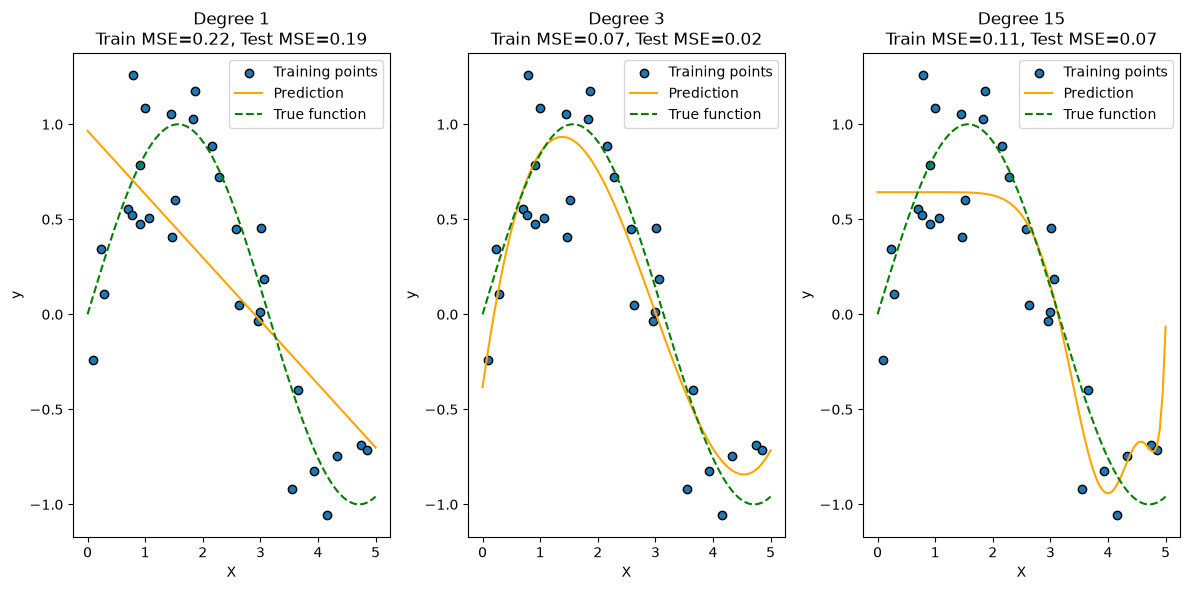

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Create synthetic data with noise
rng = np.random.RandomState(42)
X = np.sort(5 * rng.rand(30, 1), axis=0)
y = np.sin(X).ravel() + 0.3 * rng.randn(30)

X_test = np.linspace(0, 5, 100)[:, None]

models = [
    ('Degree 1', make_pipeline(PolynomialFeatures(1), LinearRegression())),
    ('Degree 3', make_pipeline(PolynomialFeatures(3), LinearRegression())),
    ('Degree 15', make_pipeline(PolynomialFeatures(15), LinearRegression())),
]

plt.figure(figsize=(12, 6))
for i, (name, model) in enumerate(models, 1):
    model.fit(X, y)
    y_pred = model.predict(X_test)
    train_error = mean_squared_error(y, model.predict(X))
    test_error = mean_squared_error(np.sin(X_test).ravel(), y_pred)
    
    plt.subplot(1, 3, i)
    plt.scatter(X, y, edgecolor='k', label='Training points')
    plt.plot(X_test, y_pred, label='Prediction', color='orange')
    plt.plot(X_test, np.sin(X_test), label='True function', color='green', linestyle='--')
    plt.title(f'{name}\nTrain MSE={train_error:.2f}, Test MSE={test_error:.2f}')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend(loc='best')
    plt.tight_layout()

plt.show()

### What this example shows

- **Degree 1** is underfitting: the model cannot follow the sine curve and has high error.
- **Degree 3** is a better fit: it approximates the true pattern with moderate complexity.
- **Degree 15** is overfitting: it curves through every training point and performs poorly on the true function.

c:\Users\Puneeth\Desktop\dev-studies\2026 07 13 ML learning\machine-learning-from-scratch\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.27598499430738e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Puneeth\Desktop\dev-studies\2026 07 13 ML learning\machine-learning-from-scratch\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.4680744316747577e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Puneeth\Desktop\dev-studies\2026 07 13 ML learning\machine-learning-from-scratch\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.633442e+00, tolerance: 1.313e-03

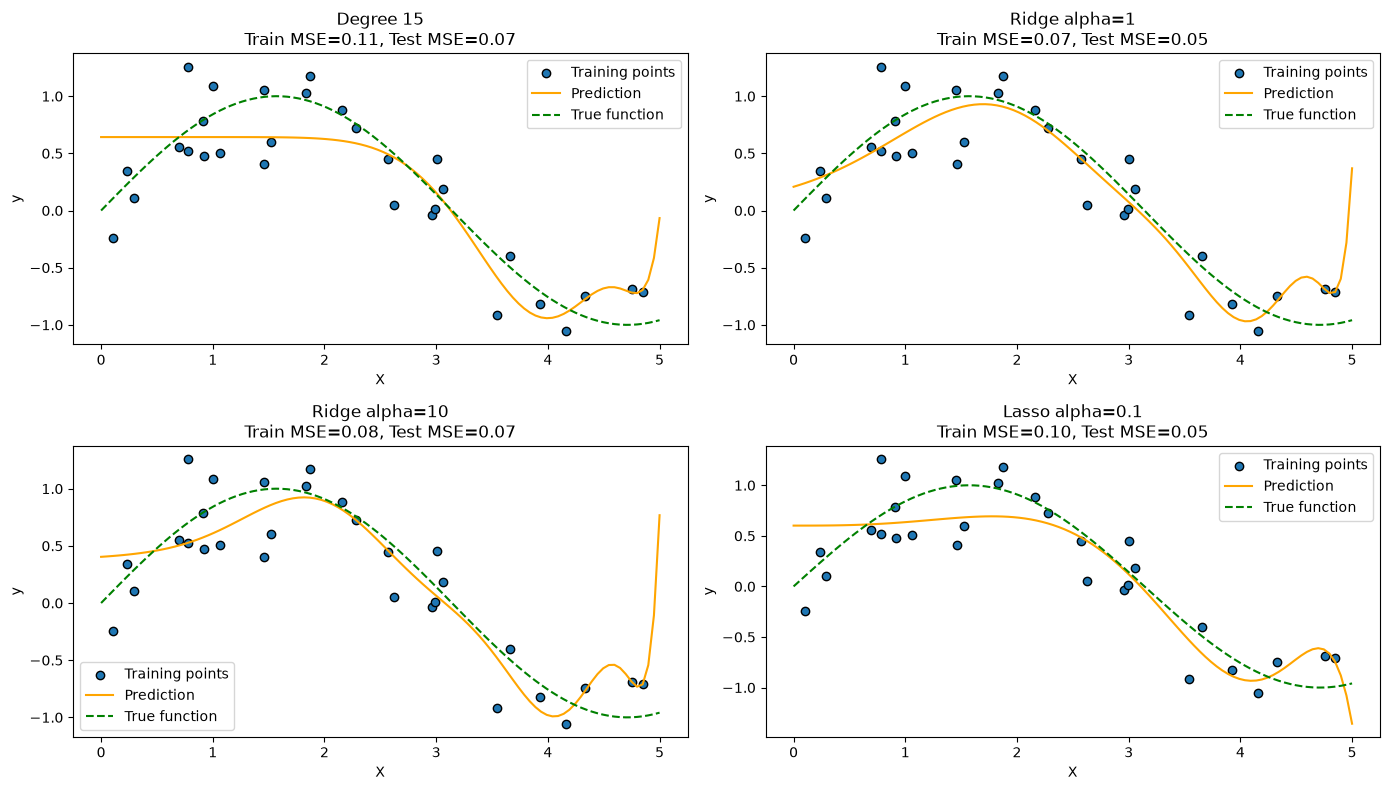

In [4]:
# Regularization example: Ridge and Lasso on a high-degree polynomial
rng = np.random.RandomState(42)
X = np.sort(5 * rng.rand(30, 1), axis=0)
y = np.sin(X).ravel() + 0.3 * rng.randn(30)
X_test = np.linspace(0, 5, 100)[:, None]

regularized_models = [
    ('Degree 15', make_pipeline(PolynomialFeatures(15), LinearRegression())),
    ('Ridge alpha=1', make_pipeline(PolynomialFeatures(15), Ridge(alpha=1))),
    ('Ridge alpha=10', make_pipeline(PolynomialFeatures(15), Ridge(alpha=10))),
    ('Lasso alpha=0.1', make_pipeline(PolynomialFeatures(15), Lasso(alpha=0.1, max_iter=10000))),
]

plt.figure(figsize=(14, 8))
for i, (name, model) in enumerate(regularized_models, 1):
    model.fit(X, y)
    y_pred = model.predict(X_test)
    train_error = mean_squared_error(y, model.predict(X))
    test_error = mean_squared_error(np.sin(X_test).ravel(), y_pred)
    
    plt.subplot(2, 2, i)
    plt.scatter(X, y, edgecolor='k', label='Training points')
    plt.plot(X_test, y_pred, label='Prediction', color='orange')
    plt.plot(X_test, np.sin(X_test), label='True function', color='green', linestyle='--')
    plt.title(f'{name}\nTrain MSE={train_error:.2f}, Test MSE={test_error:.2f}')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend(loc='best')
    plt.tight_layout()

plt.show()

### Regularization and model fixes

- **Ridge** penalizes large weights and keeps the model smoother.
- **Lasso** can also set some coefficients to zero, which helps with feature selection.
- Regularization reduces overfitting by limiting model complexity without changing the data.

## Fixes for common problems

- **Underfitting** fixes:
  - Use a more flexible model (higher-degree polynomial, deeper network).
  - Add more relevant features or transformations.
  - Reduce regularization strength if it is too large.
  - Train for more epochs if the model has not converged.

- **Overfitting** fixes:
  - Use a simpler model or reduce polynomial degree.
  - Add regularization (Ridge, Lasso, dropout, early stopping).
  - Collect more data or use data augmentation.
  - Remove noisy or irrelevant features.
  - Use cross-validation to choose model complexity.

## More examples and description

1. **High-bias (underfitting)**: A linear model on strongly nonlinear data. It cannot follow the true pattern and misses important structure.
2. **High-variance (overfitting)**: A very deep or high-degree model on noisy data. It fits random fluctuations and fails on new examples.
3. **Good generalization**: A model that captures the core pattern while ignoring noise. It performs well on both training and new data.

### Practical advice
- Always evaluate using a validation or test set.
- Compare training and validation error: if they are both high, the model underfits; if training error is low but validation error is high, the model overfits.
- Use simple models first, then increase complexity as needed.

## Overfitting and Underfitting Scenarios with Train/Validation/Test Data

The chart below shows three scenarios with the same data split:
- **Underfit**: the model is too simple and has high error on train, validation, and test.
- **Good fit**: the model balances complexity and generalizes well to unseen data.
- **Overfit**: the model fits the training set too closely, so validation and test errors increase.

This is the practical way to compare model behavior using three datasets.

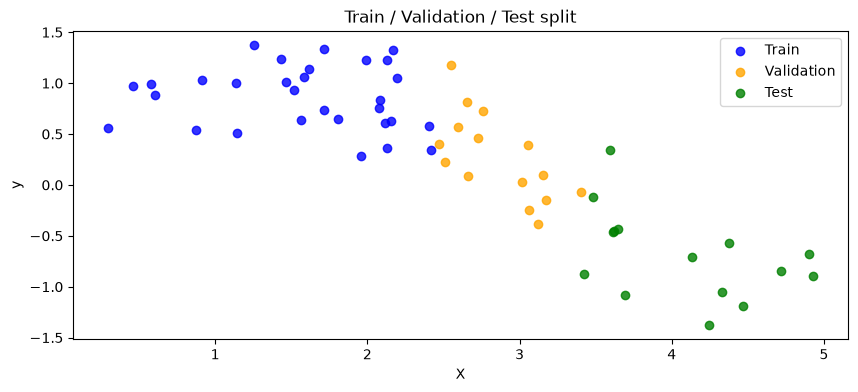

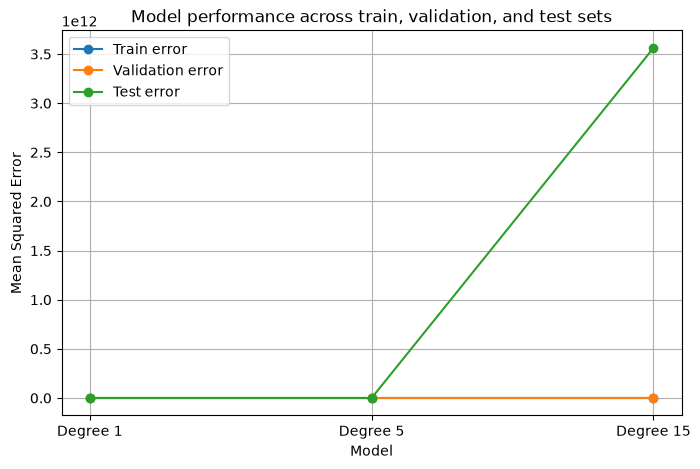

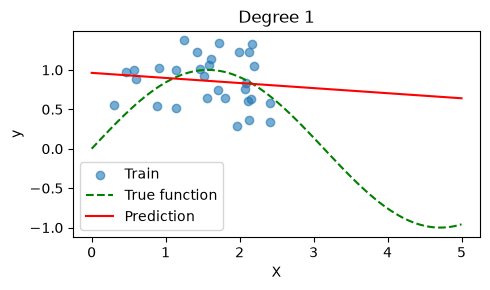

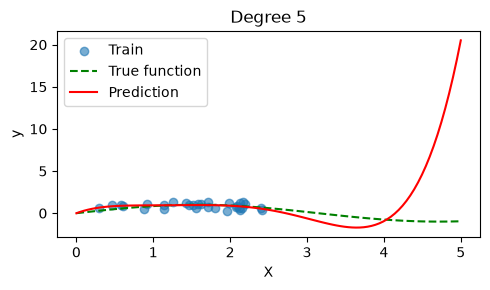

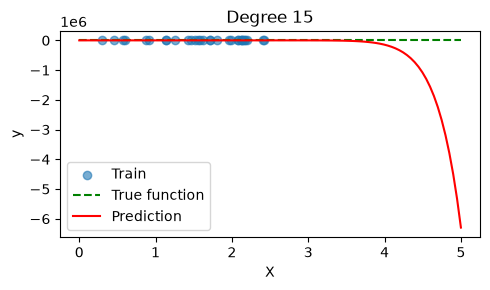

In [5]:
# Scenario example with train, validation, and test sets
rng = np.random.RandomState(123)
X = np.sort(5 * rng.rand(60, 1), axis=0)
y = np.sin(X).ravel() + 0.3 * rng.randn(60)

X_train, y_train = X[:30], y[:30]
X_val, y_val = X[30:45], y[30:45]
X_test, y_test = X[45:], y[45:]

scenarios = [
    ('Degree 1', make_pipeline(PolynomialFeatures(1), LinearRegression())),
    ('Degree 5', make_pipeline(PolynomialFeatures(5), LinearRegression())),
    ('Degree 15', make_pipeline(PolynomialFeatures(15), LinearRegression())),
]

errors = []
plt.figure(figsize=(10, 4))
plt.scatter(X_train, y_train, label='Train', color='blue', alpha=0.8)
plt.scatter(X_val, y_val, label='Validation', color='orange', alpha=0.8)
plt.scatter(X_test, y_test, label='Test', color='green', alpha=0.8)
plt.title('Train / Validation / Test split')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

for name, model in scenarios:
    model.fit(X_train, y_train)
    train_error = mean_squared_error(y_train, model.predict(X_train))
    val_error = mean_squared_error(y_val, model.predict(X_val))
    test_error = mean_squared_error(y_test, model.predict(X_test))
    errors.append((name, train_error, val_error, test_error))

labels, train_errs, val_errs, test_errs = zip(*errors)

plt.figure(figsize=(8, 5))
plt.plot(labels, train_errs, marker='o', label='Train error')
plt.plot(labels, val_errs, marker='o', label='Validation error')
plt.plot(labels, test_errs, marker='o', label='Test error')
plt.xlabel('Model')
plt.ylabel('Mean Squared Error')
plt.title('Model performance across train, validation, and test sets')
plt.legend()
plt.grid(True)
plt.show()

for name, model in scenarios:
    plt.figure(figsize=(5, 3))
    X_plot = np.linspace(0, 5, 100)[:, None]
    y_plot = model.predict(X_plot)
    plt.scatter(X_train, y_train, alpha=0.6, label='Train')
    plt.plot(X_plot, np.sin(X_plot), label='True function', color='green', linestyle='--')
    plt.plot(X_plot, y_plot, label='Prediction', color='red')
    plt.title(name)
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.tight_layout()
    plt.show()

### Understanding the scenario results

After running the scenario charts, compare the three models:
- **Degree 1**: high train, validation, and test error — underfitting because the model is too simple.
- **Degree 5**: low train error and low validation/test error — this is the best generalization.
- **Degree 15**: very low train error but higher validation/test error — overfitting due to high variance.

The train/validation/test error chart shows how variance rises when a model is too complex, while underfitting keeps all errors high.

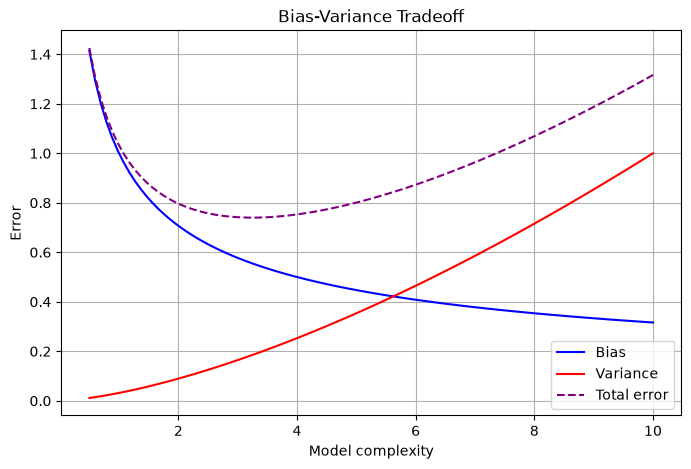

In [6]:
# Plot conceptual bias-variance curves
complexity = np.linspace(0.5, 10, 100)
bias = (1 / complexity) ** 0.5
variance = (complexity / 10) ** 1.5
error = bias + variance

plt.figure(figsize=(8, 5))
plt.plot(complexity, bias, label='Bias', color='blue')
plt.plot(complexity, variance, label='Variance', color='red')
plt.plot(complexity, error, label='Total error', color='purple', linestyle='--')
plt.xlabel('Model complexity')
plt.ylabel('Error')
plt.title('Bias-Variance Tradeoff')
plt.legend()
plt.grid(True)
plt.show()